# Laboratorio 10 — Exploración de distribuciones de probabilidad

En este laboratorio analizaremos una base de datos simulada para observar cómo diferentes variables pueden presentar distintas distribuciones.

Trabajaremos con variables generadas a partir de cuatro distribuciones de probabilidad:

- **Binomial**
- **Poisson**
- **Exponencial**
- **Normal**

### Objetivos

- Identificar variables discretas y continuas.
- Visualizar la distribución de los datos.
- Comparar la forma de diferentes distribuciones.
- Analizar con mayor detalle la distribución normal.
- Relacionar la media y la desviación estándar con el centro y la dispersión de los datos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Carga de la base de datos

La base `datos_distribuciones.csv` contiene **1.000 observaciones simuladas**.

Cada variable fue generada utilizando una distribución de probabilidad diferente. Esto nos permitirá observar cómo cambia la forma de los datos dependiendo del modelo utilizado.

In [2]:
datos = pd.read_csv("/content/datos_distribuciones.csv")
datos.head()

,id,compras_exitosas,errores_hora,tiempo_respuesta,peso_producto
0,1,7,5,0.080113,546.827611
1,2,3,4,7.569356,524.451797
2,3,5,2,0.555077,500.940658
3,4,6,5,2.177190,493.162475
4,5,8,8,3.653941,504.966896


In [3]:
print("Dimensiones de la base:", datos.shape)
datos.info()

Dimensiones de la base: (1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1000 non-null   int64  
 1   compras_exitosas  1000 non-null   int64  
 2   errores_hora      1000 non-null   int64  
 3   tiempo_respuesta  1000 non-null   float64
 4   peso_producto     1000 non-null   float64
dtypes: float64(2), int64(3)
memory usage: 39.2 KB


In [4]:
datos.describe()

,id,compras_exitosas,errores_hora,tiempo_respuesta,peso_producto
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,6.070000,2.979000,2.024574,498.665934
std,288.819436,1.550969,1.693348,2.043844,24.989768
min,1.000000,1.000000,0.000000,0.012406,410.448435
25%,250.750000,5.000000,2.000000,0.582601,482.774230
50%,500.500000,6.000000,3.000000,1.355274,499.283067
75%,750.250000,7.000000,4.000000,2.708473,515.348200
max,1000.000000,10.000000,9.000000,14.678001,575.367793


## 4. Visualización de las distribuciones

Las medidas descriptivas permiten conocer características como el centro,
la dispersión y el rango de los datos. Sin embargo, no permiten observar
directamente la **forma de una distribución**.

A continuación construiremos histogramas para analizar cómo se distribuyen
los valores de cada variable.

### Antes de observar las gráficas

A partir de los estadísticos descriptivos:

1. ¿Qué variable presenta el mayor rango de valores?
2. ¿Qué diferencia observa entre la media y la mediana de `tiempo_respuesta`?
3. ¿Qué diferencia observa entre la media y la mediana de `peso_producto`?
4. ¿Qué podría sugerir esto sobre la forma de ambas distribuciones?

## 5. Distribuciones de variables discretas

Comenzaremos analizando las variables `compras_exitosas` y `errores_hora`.

Ambas son **variables aleatorias discretas**, ya que representan conteos
y solamente pueden tomar determinados valores enteros.

Recordemos que, durante la simulación:

- `compras_exitosas` fue generada mediante una distribución **Binomial**.
- `errores_hora` fue generada mediante una distribución **Poisson**.

El objetivo no es estudiar matemáticamente estas distribuciones, sino
observar cómo se distribuyen sus valores.

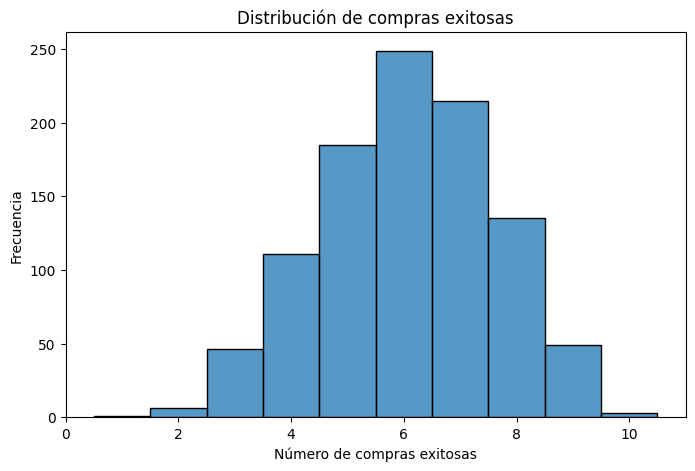

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=datos,
    x="compras_exitosas",
    discrete=True
)
plt.title("Distribución de compras exitosas")
plt.xlabel("Número de compras exitosas")
plt.ylabel("Frecuencia")

plt.show()

### Análisis de `compras_exitosas`

A partir de la gráfica, responda:

1. ¿La variable toma valores discretos o continuos?
2. ¿En qué valores se concentra la mayor cantidad de observaciones?
3. ¿Los valores aparecen con la misma frecuencia? Explique lo que observa.

## 6. Distribución de errores por hora

La variable `errores_hora` representa el número de errores registrados durante una hora.

Esta variable fue simulada utilizando una distribución de **Poisson**, un modelo de probabilidad utilizado para representar conteos de eventos.

Vamos a observar cómo se distribuyen sus valores.

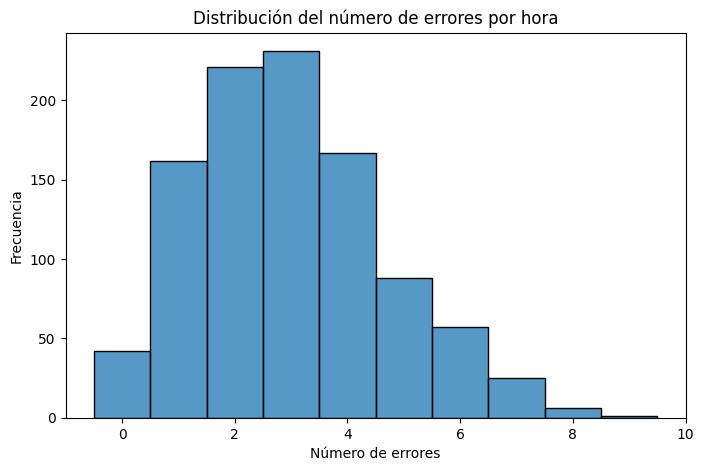

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=datos,
    x="errores_hora",
    discrete=True
)

plt.title("Distribución del número de errores por hora")
plt.xlabel("Número de errores")
plt.ylabel("Frecuencia")

plt.show()

### Análisis de `errores_hora`

A partir de la gráfica, responda:

1. ¿La variable es discreta o continua?
2. ¿Alrededor de qué valores se concentra la mayor cantidad de observaciones?
3. ¿Todos los posibles números de errores aparecen con la misma frecuencia?
4. ¿Qué diferencias observa respecto a la distribución de `compras_exitosas`?

## 7. Distribución de una variable continua

Ahora analizaremos la variable `tiempo_respuesta`, que representa el tiempo transcurrido entre solicitudes.

Esta variable es **continua**, ya que puede tomar cualquier valor dentro de un intervalo.

Durante la simulación, `tiempo_respuesta` fue generada mediante una distribución **Exponencial**.

Recordemos que en el análisis descriptivo obtuvimos aproximadamente:

- Media: **2.02 minutos**
- Mediana: **1.36 minutos**
- Máximo: **14.68 minutos**

La diferencia entre la media y la mediana ya sugería que la distribución podría presentar **asimetría**.

Vamos a observar su forma.

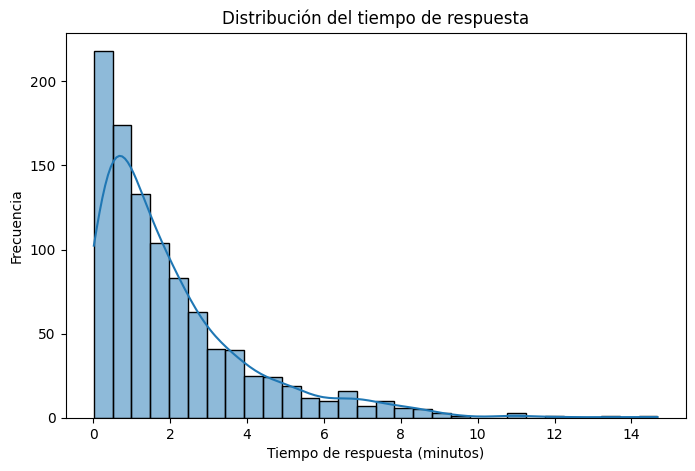

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=datos,
    x="tiempo_respuesta",
    bins=30,
    kde=True
)
plt.title("Distribución del tiempo de respuesta")
plt.xlabel("Tiempo de respuesta (minutos)")
plt.ylabel("Frecuencia")
plt.show()

### Análisis de la distribución

Observe la distribución de `tiempo_respuesta` y responda:

1. ¿La distribución es simétrica o asimétrica? ¿Hacia qué dirección se extiende la cola?

2. ¿En qué zona se concentra la mayor cantidad de observaciones?

3. ¿Qué ocurre con la frecuencia a medida que aumenta el tiempo de respuesta?

4. ¿La distribución observada tiene las características de una distribución normal? Justifique su respuesta.

## 8. Distribución del peso de los productos

Ahora analizaremos la variable `peso_producto`.

Esta variable es **continua** y fue generada mediante una distribución Normal.

A diferencia de `tiempo_respuesta`, observaremos cómo cambia la forma de la distribución cuando los valores se concentran alrededor de una media de manera aproximadamente simétrica.

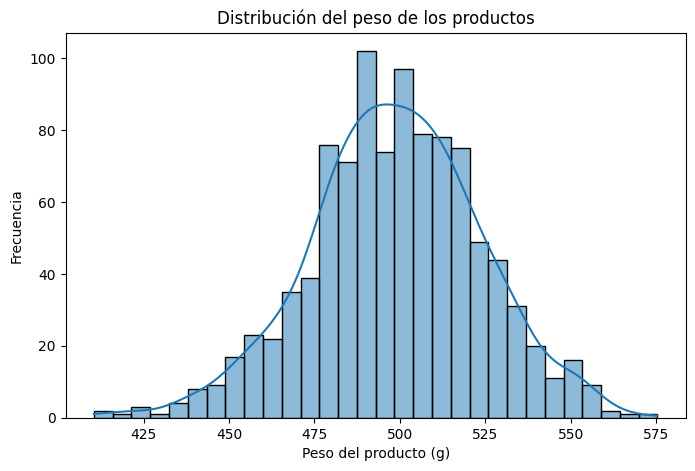

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=datos,
    x="peso_producto",
    bins=30,
    kde=True
)
plt.title("Distribución del peso de los productos")
plt.xlabel("Peso del producto (g)")
plt.ylabel("Frecuencia")

plt.show()

### Análisis de la distribución

Observe la distribución de `peso_producto` y responda:

1. ¿La distribución es aproximadamente simétrica o asimétrica?

2. ¿Alrededor de qué valor parece concentrarse la mayor cantidad de observaciones?

3. ¿Qué ocurre con la frecuencia a medida que nos alejamos del centro de la distribución?

4. ¿Qué características observadas permiten afirmar que esta variable presenta una forma aproximadamente normal?

5. Compare esta gráfica con la distribución de `tiempo_respuesta`. ¿Qué diferencias encuentra entre ambas, teniendo en cuenta que las dos variables son continuas?

## 9. Media y desviación estándar

En una distribución Normal, la **media** determina el centro de la distribución,
mientras que la **desviación estándar** describe qué tan dispersos se encuentran
los valores alrededor de ese centro.

Calculemos estas medidas para la variable `peso_producto`.

In [9]:
media_peso = datos["peso_producto"].mean()
desviacion_peso = datos["peso_producto"].std()
print(f"Media: {media_peso:.2f} g")
print(f"Desviación estándar: {desviacion_peso:.2f} g")

Media: 498.67 g
Desviación estándar: 24.99 g


### Interpretación

A partir de los resultados obtenidos y de la gráfica anterior, responda:

1. ¿Alrededor de qué valor se encuentra centrada la distribución?

2. ¿Qué representa la desviación estándar obtenida?

3. ¿Los valores calculados son coherentes con la forma observada en el histograma? Explique.

4. ¿Qué diferencia principal encontró entre las distribuciones de
   `tiempo_respuesta` y `peso_producto`?